In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv(r"C:\Users\krish\Downloads\data.csv\data.csv", encoding="latin1"
)
print(df)

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  CustomerID         Country  
0        1

In [2]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [3]:
df = df.dropna(subset=['CustomerID'])

In [4]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [5]:
df = df[df['Quantity'] > 0]

In [6]:
df = df[df['UnitPrice'] > 0]

In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [8]:
df['Month'] = df['InvoiceDate'].dt.strftime('%Y-%m')

In [9]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [10]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Month', 'Revenue'],
      dtype='object')


In [11]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [12]:
print(df[['Quantity', 'UnitPrice', 'Revenue']].head())

   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34


In [13]:
total_revenue = df['Revenue'].sum()

total_orders = df['InvoiceNo'].nunique()

total_customers = df['CustomerID'].nunique()

avg_order_value = total_revenue / total_orders

print(total_revenue)
print(total_orders)
print(total_customers)
print(avg_order_value)

8911407.904
18532
4338
480.8659563997409


In [14]:
top_products = (
    df.groupby('Description')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64


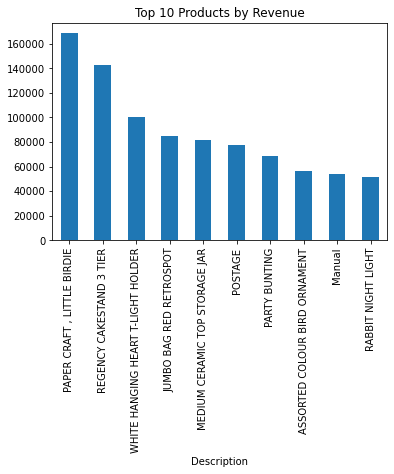

In [15]:
import matplotlib.pyplot as plt

top_products.plot(kind='bar')

plt.title("Top 10 Products by Revenue")
plt.show()


In [16]:
country_sales = (
    df.groupby('Country')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(country_sales)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64


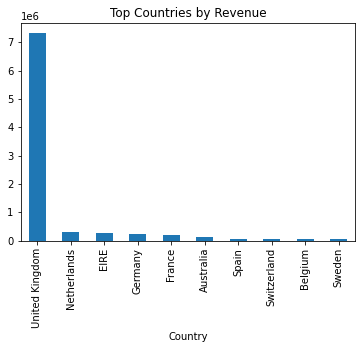

In [17]:
country_sales.plot(kind='bar')

plt.title("Top Countries by Revenue")
plt.show()

In [18]:
print(df['InvoiceDate'].dtype)

datetime64[ns]


In [19]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    format='%m/%d/%Y %H:%M'
)

In [20]:
print(df['InvoiceDate'].dtype)

datetime64[ns]


In [21]:
df['Month'] = df['InvoiceDate'].dt.strftime('%Y-%m')

In [22]:
monthly_sales = df.groupby('Month')['Revenue'].sum()

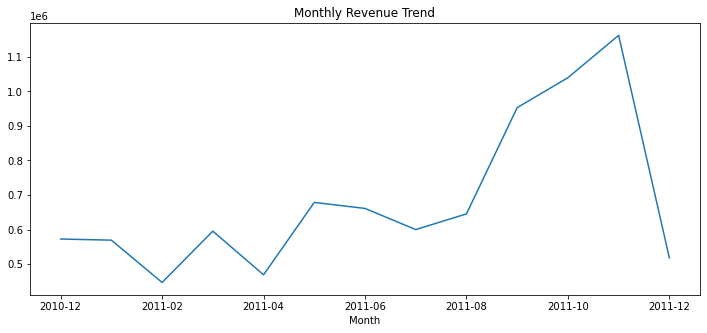

In [23]:
monthly_sales.plot(figsize=(12,5))

plt.title("Monthly Revenue Trend")
plt.show()

In [24]:
top_customers = (
    df.groupby('CustomerID')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64


In [25]:
import sqlite3

conn = sqlite3.connect("ecommerce.db")

df.to_sql("Orders", conn, if_exists='replace', index=False)

397884

In [26]:
pd.read_sql(
    "SELECT COUNT(*) FROM Orders;",
    conn
)

,COUNT(*)
0,397884


In [27]:
query = """
SELECT SUM(Revenue) AS Total_Revenue
FROM Orders
"""

result = pd.read_sql(query, conn)
print(result)

   Total_Revenue
0   8.911408e+06


In [28]:
sql_query = """
SELECT Description,
       SUM(Revenue) AS Revenue
FROM Orders
GROUP BY Description
ORDER BY Revenue DESC
LIMIT 10;
"""
result = pd.read_sql(sql_query, conn)
print(result)

                          Description    Revenue
0         PAPER CRAFT , LITTLE BIRDIE  168469.60
1            REGENCY CAKESTAND 3 TIER  142592.95
2  WHITE HANGING HEART T-LIGHT HOLDER  100448.15
3             JUMBO BAG RED RETROSPOT   85220.78
4      MEDIUM CERAMIC TOP STORAGE JAR   81416.73
5                             POSTAGE   77803.96
6                       PARTY BUNTING   68844.33
7       ASSORTED COLOUR BIRD ORNAMENT   56580.34
8                              Manual   53779.93
9                  RABBIT NIGHT LIGHT   51346.20


In [29]:
sql_query = """
SELECT Country,
       SUM(Revenue) AS Revenue
FROM Orders
GROUP BY Country
ORDER BY Revenue DESC;
"""
result = pd.read_sql(sql_query, conn)
print(result)

                 Country       Revenue
0         United Kingdom  7.308392e+06
1            Netherlands  2.854463e+05
2                   EIRE  2.655459e+05
3                Germany  2.288671e+05
4                 France  2.090240e+05
5              Australia  1.385213e+05
6                  Spain  6.157711e+04
7            Switzerland  5.644395e+04
8                Belgium  4.119634e+04
9                 Sweden  3.837833e+04
10                 Japan  3.741637e+04
11                Norway  3.616544e+04
12              Portugal  3.343989e+04
13               Finland  2.254608e+04
14             Singapore  2.127929e+04
15       Channel Islands  2.045044e+04
16               Denmark  1.895534e+04
17                 Italy  1.748324e+04
18                Cyprus  1.359038e+04
19               Austria  1.019868e+04
20                Poland  7.334650e+03
21                Israel  7.221690e+03
22                Greece  4.760520e+03
23               Iceland  4.310000e+03
24                Canada 

In [30]:
sql_query = """
SELECT CustomerID,
       SUM(Revenue) AS Revenue
FROM Orders
GROUP BY CustomerID
ORDER BY Revenue DESC;
"""

result1 = pd.read_sql(sql_query, conn)
print(result1)

      CustomerID    Revenue
0        14646.0  280206.02
1        18102.0  259657.30
2        17450.0  194550.79
3        16446.0  168472.50
4        14911.0  143825.06
...          ...        ...
4333     16878.0      13.30
4334     17956.0      12.75
4335     16454.0       6.90
4336     14792.0       6.20
4337     16738.0       3.75

[4338 rows x 2 columns]


In [31]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [32]:
top_products = df.groupby('Description')['Revenue'].sum() \
                 .sort_values(ascending=False) \
                 .head(10)

In [33]:
country_sales = df.groupby('Country')['Revenue'].sum() \
                  .sort_values(ascending=False)

In [34]:
monthly_sales = df.groupby('Month')['Revenue'].sum()

In [35]:
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()

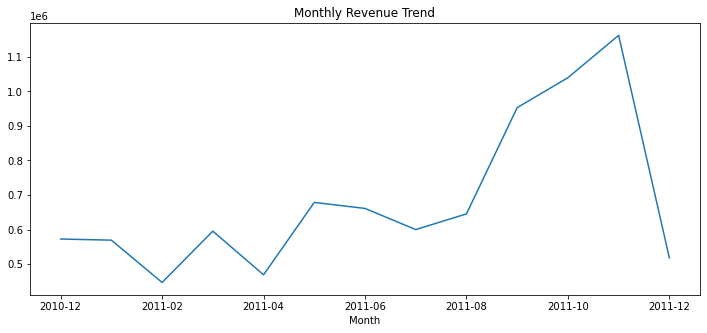

In [36]:
monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Revenue Trend")
plt.show()

<AxesSubplot:xlabel='Description'>

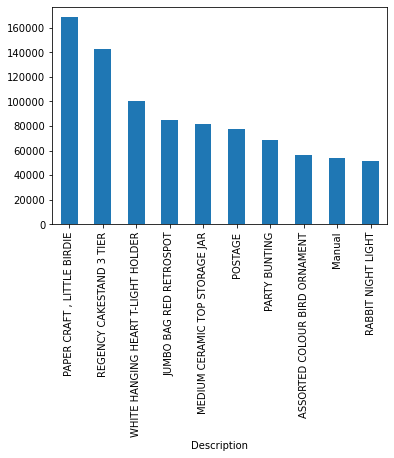

In [37]:
top_products.plot(kind='bar')

<AxesSubplot:xlabel='Country'>

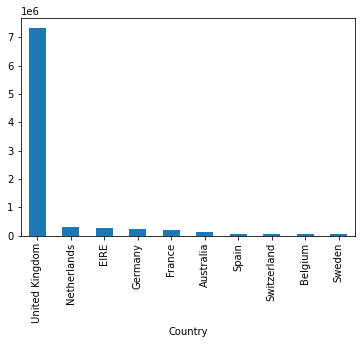

In [38]:
country_sales.head(10).plot(kind='bar')

<AxesSubplot:>

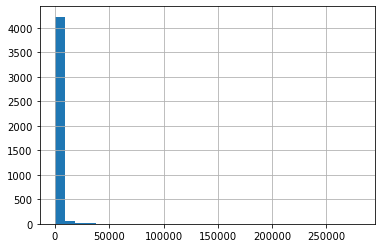

In [39]:
rfm['Monetary'].hist(bins=30)

In [40]:
df.to_csv('cleaned_ecommerce.csv', index=False)

In [42]:
df.to_csv(
    r"C:\Users\krish\Downloads\cleaned_ecommerce.csv",
    index=False
)